# Well Visualization

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path

%matplotlib widget

In [40]:
# Establish paths
base_dir = Path.cwd().parent.parent.parent
data_dir_DEL_01 = os.path.join(base_dir, 'datasets', 'well_data', 'ENTIREWELL_DEL-GT-01_Surveys_2931m_TD.xlsx')
data_dir_DEL_02 = os.path.join(base_dir, 'datasets', 'well_data', 'ENTIREWELL_DEL-GT-02-S2_Surveys_inco.xlsx')
facies_data = os.path.join(base_dir, 'datasets','well_data','Well_data.xlsx')


# Load Data
DEL_GT_01 = pd.read_excel(data_dir_DEL_01,skiprows = 19)
DEL_GT_02 = pd.read_excel(data_dir_DEL_02,skiprows = 19)
facies_DEL_GT_01 = pd.read_excel(facies_data, sheet_name='DEL-GT-01')
facies_DEL_GT_02 = pd.read_excel(facies_data, sheet_name='DEL-GT-02-S2')

In [41]:
def plot_3d_wells(ax, data, data_name, facies):
    """
    Plot 3D wells with Depth, Easting and Norting in metres.
    """
    

    if facies == True:
        grid_e = data['GRID E'].astype(float).to_numpy()
        grid_n = data['GRID N'].astype(float).to_numpy()
        depth = [-z for z in data['MD'].astype(float).to_numpy() ]
        ax.plot(grid_e,grid_n, depth, marker='o',label=data_name)
    else:
        grid_e = data['GRID E'].iloc[1:].astype(float).to_numpy()
        grid_n = data['GRID N'].iloc[1:].astype(float).to_numpy()
        depth = [-z for z in data['MD'].iloc[1:].astype(float).to_numpy() ]
        ax.plot(grid_e, grid_n, depth, linestyle='-', linewidth=2, label=data_name)

    # 4. Format the axes
    ax.set_xlabel('Grid Easting (m)', labelpad=15)
    ax.set_ylabel('Grid Northing (m)', labelpad=15)
    ax.set_zlabel('True Vertical Depth (m)', labelpad=10)
    ax.set_title('3D Wellbore Trajectory')

    ax.legend()

plotting Producer succesfull!
plotting Injector succesfull!
plotting Reservoir Section Injector succesfull!
plotting Reservoir Section Producer succesfull!


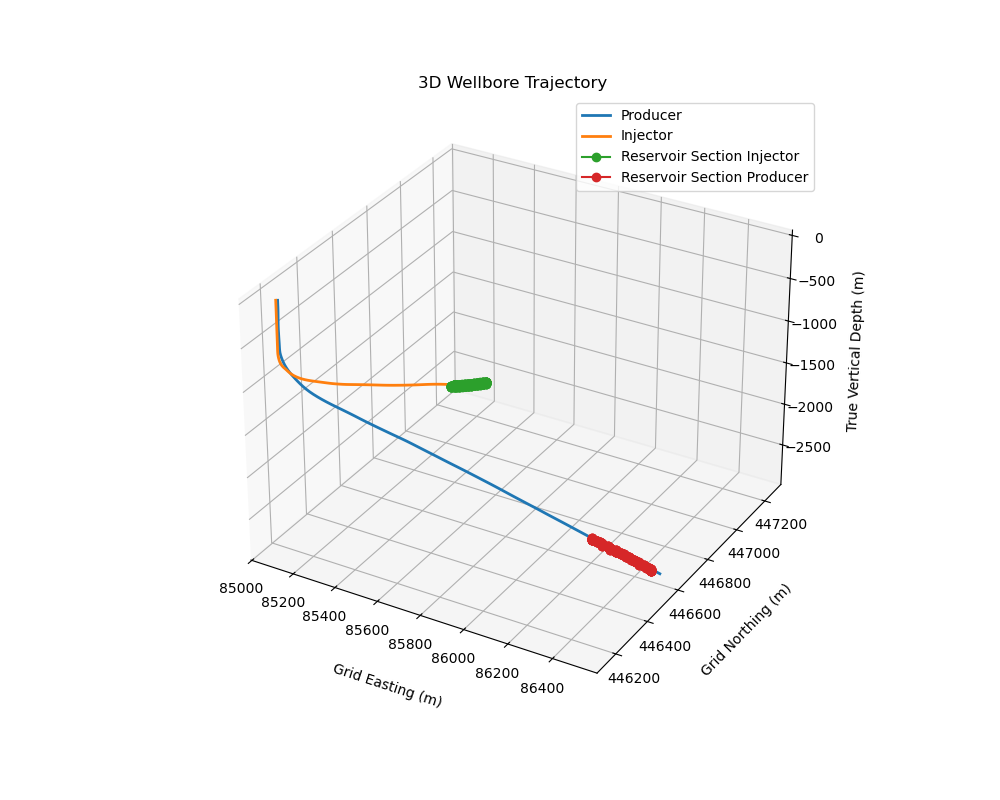

In [42]:
data = [DEL_GT_01, DEL_GT_02, facies_DEL_GT_02, facies_DEL_GT_01]
data_names = ['Producer','Injector',  'Reservoir Section Injector', 'Reservoir Section Producer']
facies = [False, False, True, True]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(data)):
    plot_3d_wells(ax, data[i],data_names[i],facies[i])
    print(f"plotting {data_names[i]} succesfull!")

plt.show()